In [1]:
import pandas as pd
import pm4py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pm_csv = pd.read_csv("../data/bpi-challenge-2017/bpi_2017_cleaned.csv")

In [3]:
pm_csv

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144


In [4]:
import pm4py
from pm4py.objects.log.util import dataframe_utils
from pm4py.visualization.bpmn import visualizer as bpmn_visualizer
from pm4py.objects.conversion.log import converter as log_converter

pm_csv = dataframe_utils.convert_timestamp_columns_in_df(pm_csv)
log = log_converter.apply(pm_csv)

#Discovery
process_tree = pm4py.discover_process_tree_inductive(log)
bpmn_model = pm4py.convert_to_bpmn(process_tree)
print("Process tree discovered successfully!")
#Performance
throughput_time = pm4py.get_all_case_durations(log)
print(f"Mean cycle time: {np.mean(throughput_time)}")

Process tree discovered successfully!
Mean cycle time: 1892125.9230699476


In [5]:
# Visualize process tree
from pm4py.visualization.process_tree import visualizer as pt_visualizer

# Vẽ process tree
gviz = pt_visualizer.apply(process_tree)
gviz.render("process_tree", format="svg", cleanup=True)
print("Process tree saved as process_tree.svg")

# In process tree dạng text
print("\nProcess Tree Structure:")
print(process_tree)

Process tree saved as process_tree.svg

Process Tree Structure:
->( 'A_Create Application', X( tau, 'A_Submitted' ), +( 'A_Accepted', 'A_Concept', X( tau, *( 'W_Assess potential fraud', tau ) ), ->( X( tau, *( 'W_Handle leads', tau ) ), *( *( ->( 'W_Complete application', X( tau, +( X( tau, *( 'W_Call after offers', tau ) ), ->( X( tau, 'A_Complete' ), X( tau, *( ->( X( tau, 'O_Cancelled', 'O_Sent (mail and online)', ->( X( tau, *( ->( 'W_Validate application', X( tau, 'A_Validating' ) ), tau ) ), X( tau, 'A_Cancelled' ) ), 'O_Sent (online only)' ), X( tau, +( X( tau, *( 'W_Call incomplete files', tau ) ), X( tau, ->( X( tau, *( 'A_Incomplete', tau ) ), X( tau, 'W_Shortened completion ', ->( 'O_Create Offer', 'O_Created' ), ->( 'A_Denied', X( tau, *( 'O_Refused', tau ) ) ), ->( X( tau, *( 'O_Returned', tau ) ), X( tau, ->( 'O_Accepted', 'A_Pending' ) ) ) ) ) ) ) ), X( tau, *( 'W_Personal Loan collection', tau ) ) ), tau ) ) ) ) ) ), tau ), tau ) ) ) )


## 📊 EXPLORATORY DATA ANALYSIS (EDA)

In [6]:
# Basic Log Statistics
num_cases = len(log)
num_events = sum(len(trace) for trace in log)
unique_activities = set()
for trace in log:
    for event in trace:
        unique_activities.add(event["concept:name"])

print("=" * 50)
print("📈 BASIC LOG STATISTICS")
print("=" * 50)
print(f"Total Cases: {num_cases:,}")
print(f"Total Events: {num_events:,}")
print(f"Unique Activities: {len(unique_activities)}")
print(f"Events per Case (avg): {num_events/num_cases:.2f}")
print(f"Date Range: {pm_csv['time:timestamp'].min()} to {pm_csv['time:timestamp'].max()}")

📈 BASIC LOG STATISTICS
Total Cases: 31,509
Total Events: 1,202,267
Unique Activities: 26
Events per Case (avg): 38.16
Date Range: 2016-01-01 09:51:15.304000+00:00 to 2017-02-01 14:11:03.499000+00:00



🎯 TOP 10 ACTIVITIES
                Activity  Frequency
  W_Validate application     209496
     W_Call after offers     191092
 W_Call incomplete files     168529
  W_Complete application     148900
          W_Handle leads      47264
          O_Create Offer      42995
               O_Created      42995
O_Sent (mail and online)      39707
            A_Validating      38816
              A_Accepted      31509


<Axes: ylabel='Activity'>

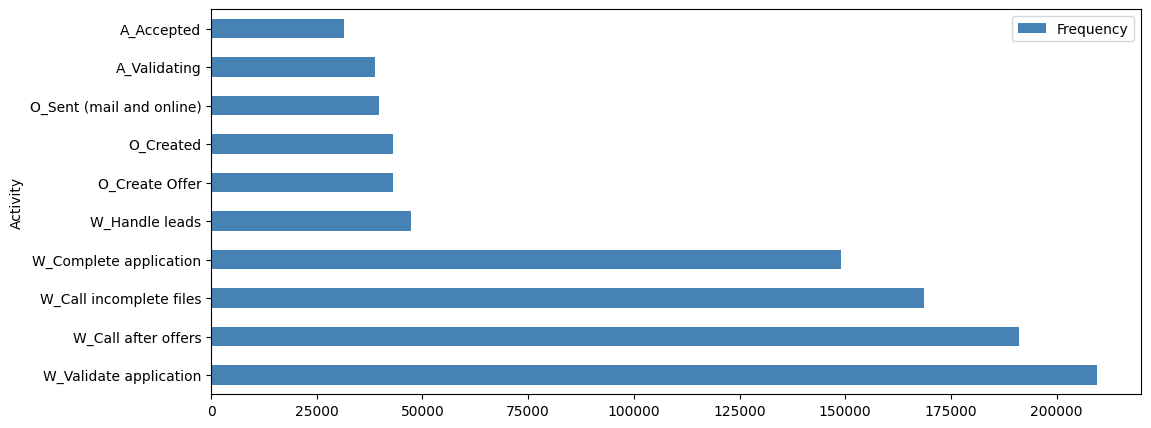

In [ ]:
# Activity Frequency Analysis

activity_freq = {}
for trace in log:
    for event in trace:
        activity = event["concept:name"]
        activity_freq[activity] = activity_freq.get(activity, 0) + 1
activity_df = pd.DataFrame(list(activity_freq.items()), columns=['Activity', 'Frequency'])
activity_df = activity_df.sort_values('Frequency', ascending=False)

print("\n" + "=" * 50)
print("🎯 TOP 10 ACTIVITIES")
print("=" * 50)
print(activity_df.head(10).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 5))
activity_df.head(10).plot(x='Activity', y='Frequency', kind='barh', ax=ax, color='steelblue')



📋 TRACE & CASE ANALYSIS
Trace Length - Min: 10, Max: 180, Avg: 38.16
Total Variants: 15930
Top 5 Variants (out of 15930):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  Variant  Count
                                                    ('A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Handle leads', 'W_Complete application', 'A_Concept', 'W_Complete application', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application', 'W_Call after offers', 'W_Call after offers', 'A_Complete', 'W_Call after offers', 'W_Call after offers'

C:\Users\Admin\AppData\Local\Temp\ipykernel_20288\1413543792.py:32: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


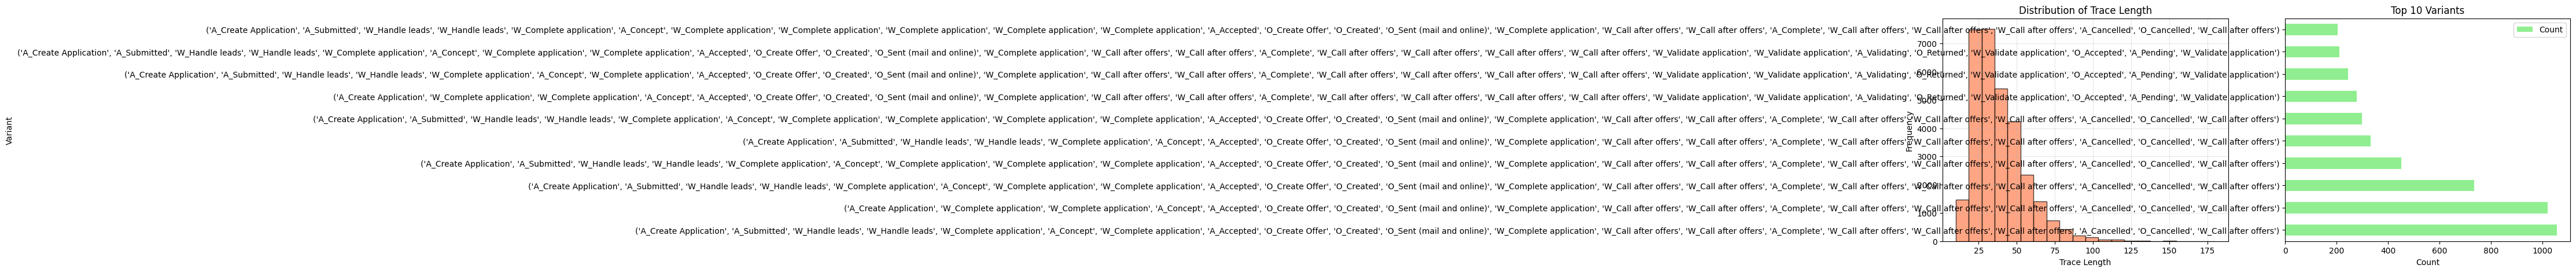

In [8]:
# Trace Length Analysis
trace_lengths = [len(trace) for trace in log]
variants = pm4py.get_variants(log)

print("\n" + "=" * 50)
print("📋 TRACE & CASE ANALYSIS")
print("=" * 50)
print(f"Trace Length - Min: {min(trace_lengths)}, Max: {max(trace_lengths)}, Avg: {np.mean(trace_lengths):.2f}")
print(f"Total Variants: {len(variants)}")
print(f"Top 5 Variants (out of {len(variants)}):")

variant_df = pd.DataFrame([(str(v), len(log_variants)) for v, log_variants in variants.items()], 
                          columns=['Variant', 'Count'])
variant_df = variant_df.sort_values('Count', ascending=False)
print(variant_df.head(5).to_string(index=False))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Trace length distribution
ax1.hist(trace_lengths, bins=20, color='coral', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Trace Length')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Trace Length')
ax1.grid(alpha=0.3)

# Top variants
variant_df.head(10).plot(x='Variant', y='Count', kind='barh', ax=ax2, color='lightgreen')
ax2.set_xlabel('Count')
ax2.set_title('Top 10 Variants')

plt.tight_layout()
plt.show()


⏱️ PERFORMANCE METRICS
Case Duration - Min: 0.00 days
Case Duration - Max: 286.07 days
Case Duration - Mean: 21.90 days
Case Duration - Median: 19.09 days
Case Duration - Std Dev: 13.17 days


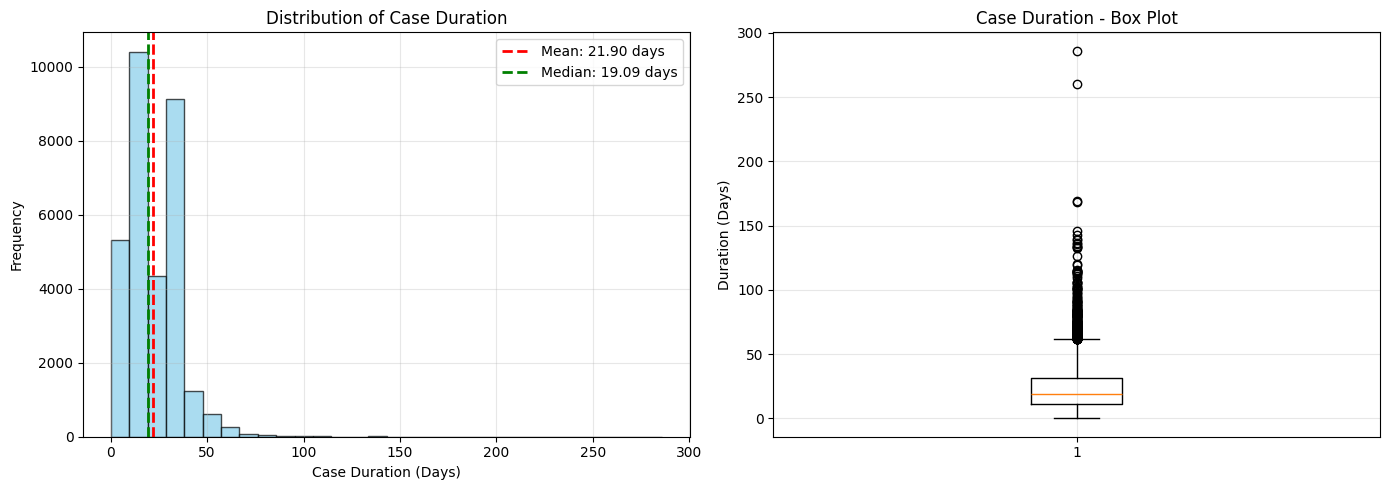

In [9]:
# Performance Analysis (Case Duration)
# Convert seconds to days (throughput_time is in seconds)
duration_seconds = throughput_time
duration_days = [sec / (24 * 3600) for sec in duration_seconds]

print("\n" + "=" * 50)
print("⏱️ PERFORMANCE METRICS")
print("=" * 50)
print(f"Case Duration - Min: {min(duration_days):.2f} days")
print(f"Case Duration - Max: {max(duration_days):.2f} days")
print(f"Case Duration - Mean: {np.mean(duration_days):.2f} days")
print(f"Case Duration - Median: {np.median(duration_days):.2f} days")
print(f"Case Duration - Std Dev: {np.std(duration_days):.2f} days")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Duration histogram
ax1.hist(duration_days, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(np.mean(duration_days), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(duration_days):.2f} days')
ax1.axvline(np.median(duration_days), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(duration_days):.2f} days')
ax1.set_xlabel('Case Duration (Days)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Case Duration')
ax1.legend()
ax1.grid(alpha=0.3)

# Box plot
ax2.boxplot(duration_days, vert=True)
ax2.set_ylabel('Duration (Days)')
ax2.set_title('Case Duration - Box Plot')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


🔄 PROCESS FLOW STATISTICS
Start Activities: {'A_Create Application': 31509}
End Activities: {'W_Validate application': 12662, 'O_Cancelled': 4436, 'W_Call after offers': 9457, 'W_Call incomplete files': 4676, 'W_Complete application': 144, 'W_Assess potential fraud': 102, 'W_Personal Loan collection': 2, 'W_Shortened completion ': 5, 'A_Denied': 1, 'O_Sent (online only)': 8, 'O_Sent (mail and online)': 15, 'O_Returned': 1}
Total Direct Follows Relations: 178

📊 Generating DFG Visualization...


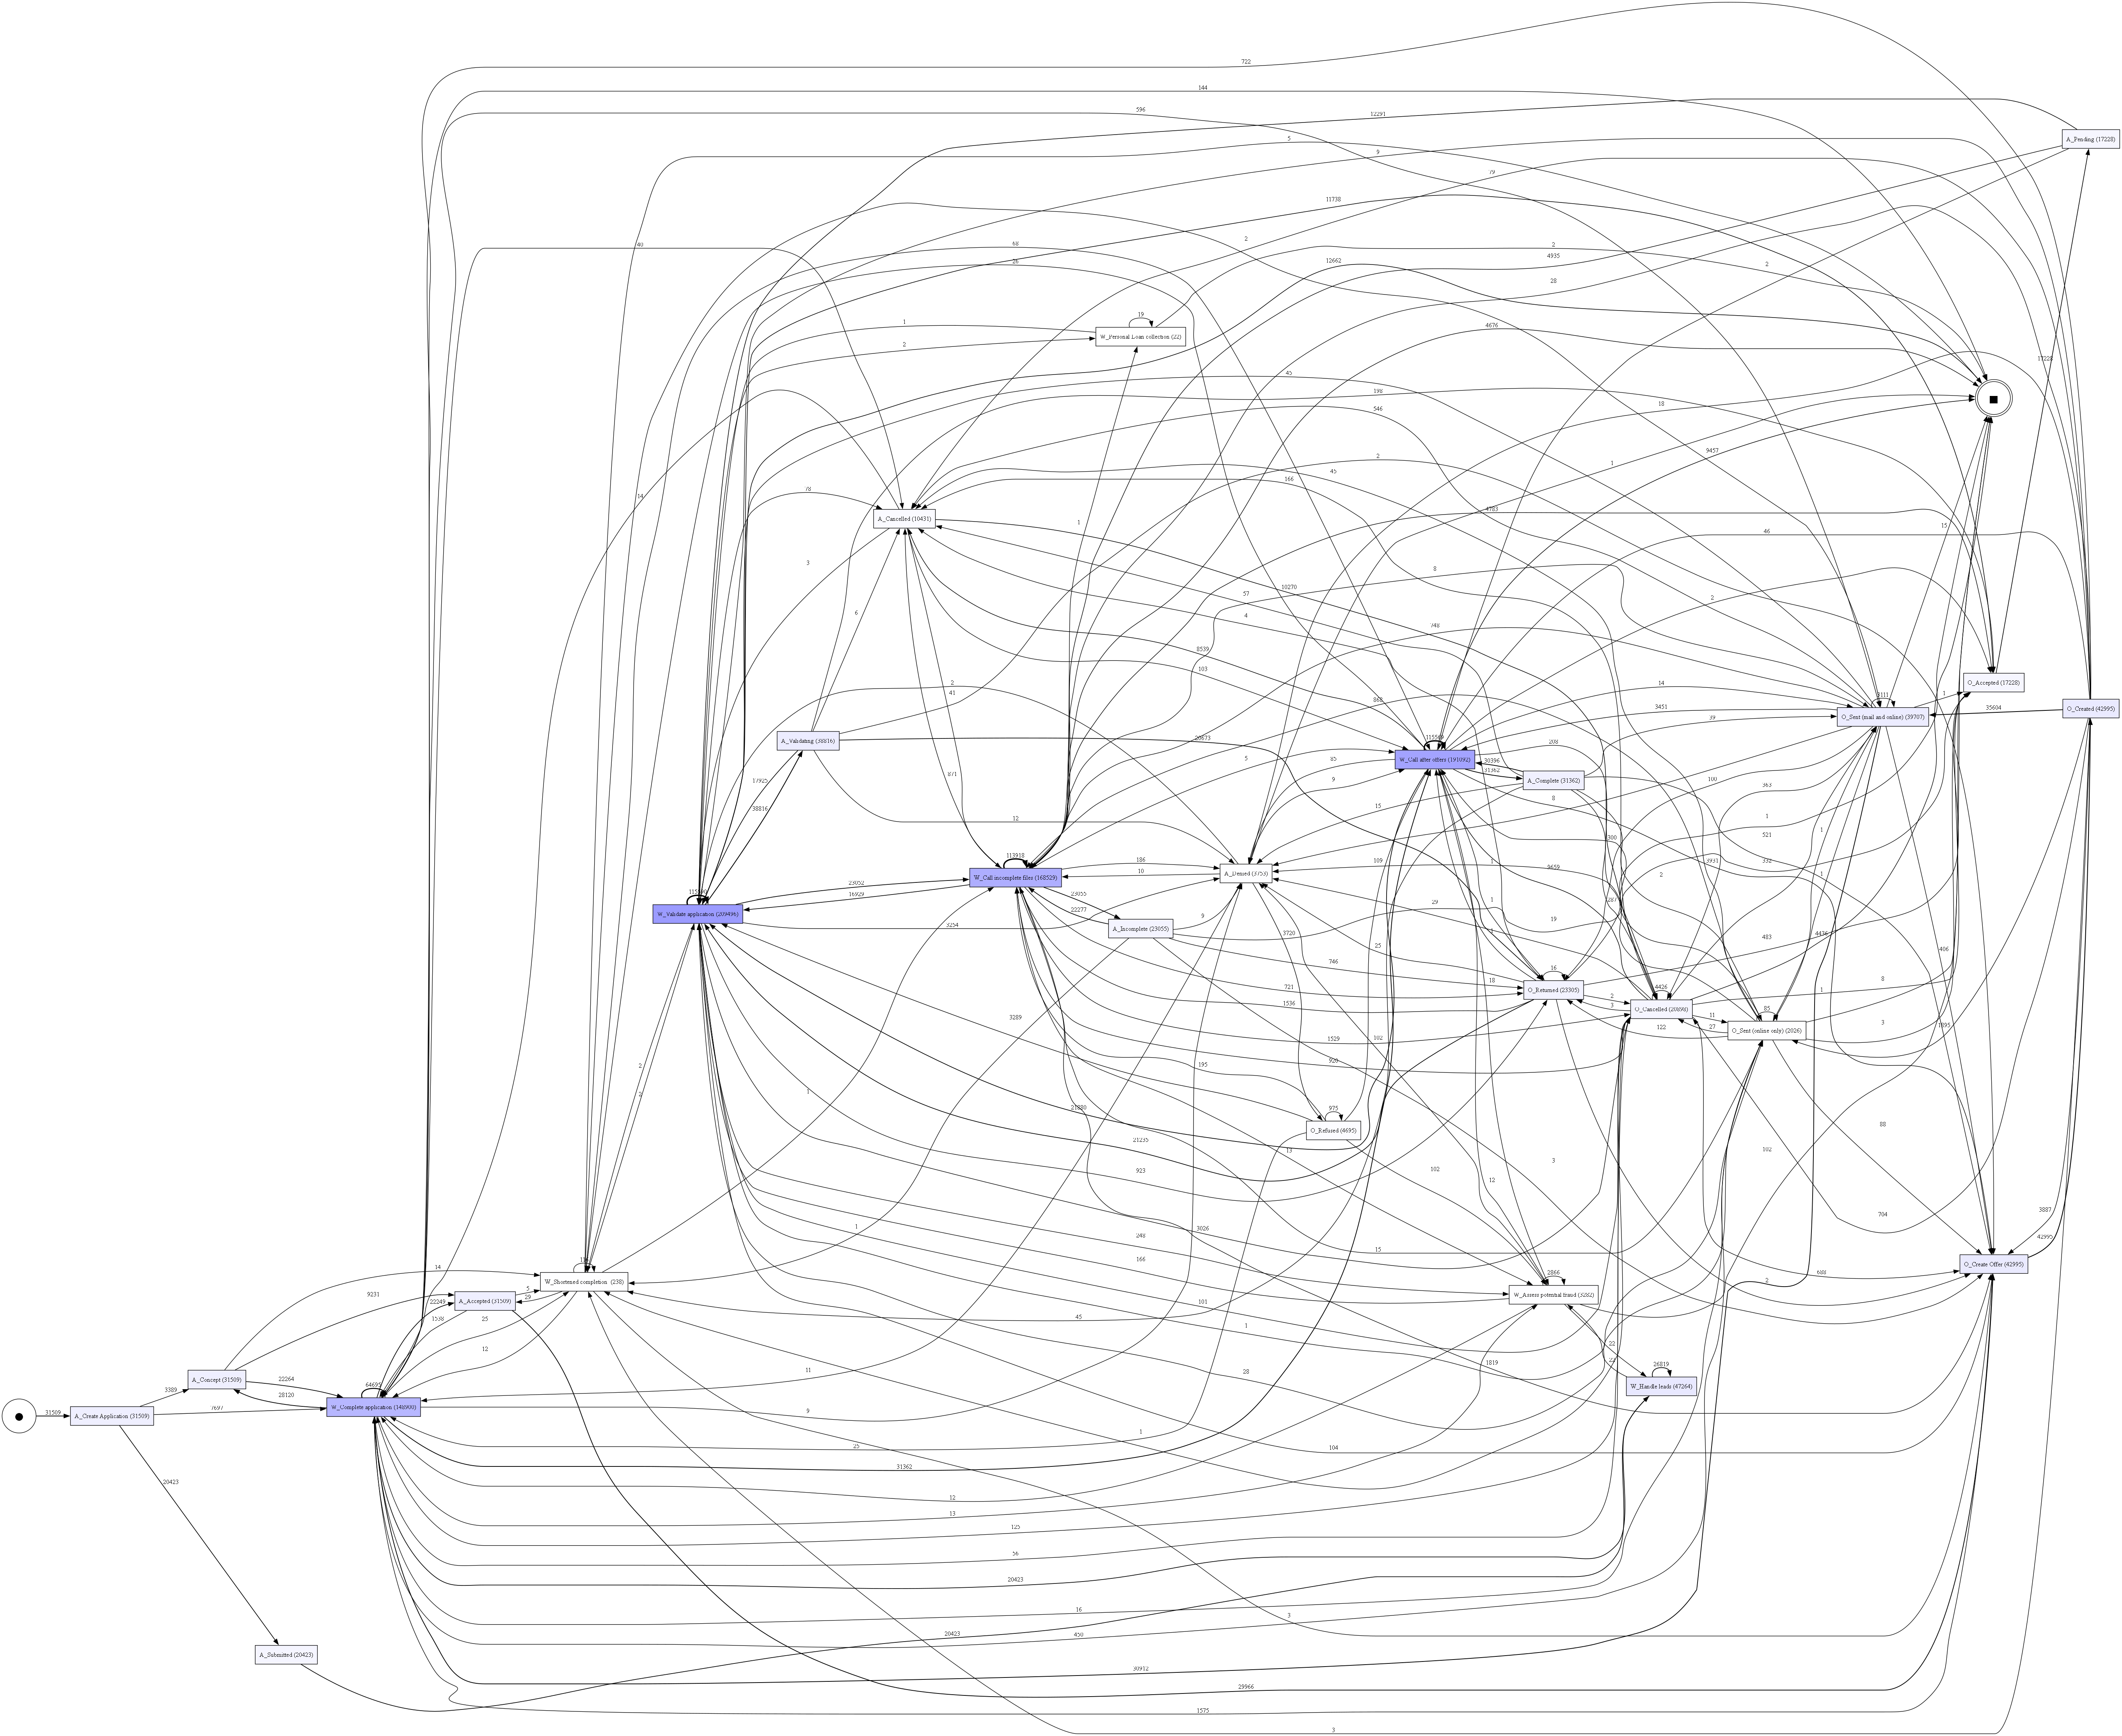

In [10]:
# Discover DFG (Directly-Follows Graph) - Clean visualization
# This shows the actual flow of activities in the log
dfg, start_activities, end_activities = pm4py.discover_dfg(log)

print("\n" + "=" * 50)
print("🔄 PROCESS FLOW STATISTICS")
print("=" * 50)
print(f"Start Activities: {start_activities}")
print(f"End Activities: {end_activities}")
print(f"Total Direct Follows Relations: {len(dfg)}")

# Visualize DFG with better parameters
print("\n📊 Generating DFG Visualization...")
pm4py.view_dfg(dfg, start_activities, end_activities)

In [11]:
# Summary and Key Insights
print("\n" + "=" * 70)
print("🎯 KEY INSIGHTS SUMMARY")
print("=" * 70)

insights = {
    "Process Complexity": "High" if len(variants) > 100 else ("Medium" if len(variants) > 20 else "Low"),
    "Process Variability": len(variants),
    "Most Complex Trace": max(trace_lengths),
    "Avg Process Duration": f"{np.mean(duration_days):.1f} days" if duration_days else "N/A",
    "Management Focus": f"Top 10 variants cover {(variant_df.head(10)['Count'].sum()/len(log)*100):.1f}% of cases",
}

for key, value in insights.items():
    print(f"  • {key}: {value}")

print("\n💡 RECOMMENDATIONS FOR NEXT STEPS:")
print("  1. Conformance Checking: Validate how well discovered model fits the log")
print("  2. Bottleneck Analysis: Identify which activities cause delays")
print("  3. Variant Analysis: Deep dive into why variants differ")
print("  4. Outlier Detection: Find anomalous cases (too long/short)")
print("=" * 70)


🎯 KEY INSIGHTS SUMMARY
  • Process Complexity: High
  • Process Variability: 15930
  • Most Complex Trace: 180
  • Avg Process Duration: 21.9 days
  • Management Focus: Top 10 variants cover 15.3% of cases

💡 RECOMMENDATIONS FOR NEXT STEPS:
  1. Conformance Checking: Validate how well discovered model fits the log
  2. Bottleneck Analysis: Identify which activities cause delays
  3. Variant Analysis: Deep dive into why variants differ
  4. Outlier Detection: Find anomalous cases (too long/short)


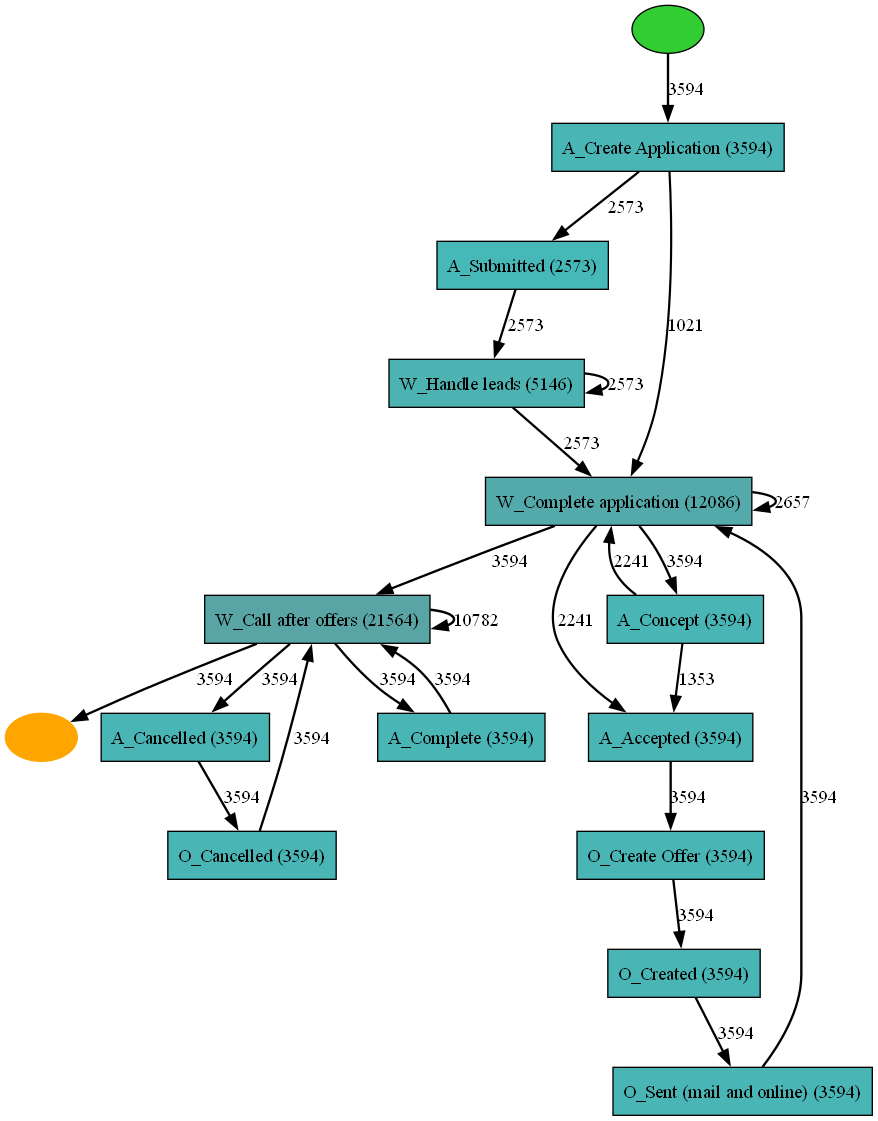

In [12]:
# Chỉ giữ lại 5 biến thể (luồng đi) phổ biến nhất
filtered_log = pm4py.filter_variants_top_k(log, k=5)

map_visual = pm4py.discover_heuristics_net(filtered_log)
pm4py.view_heuristics_net(map_visual)

Số lượng sự kiện con người (Work Items) giữ lại: 768823
Đã vẽ xong sơ đồ công việc thực tế của nhân viên!


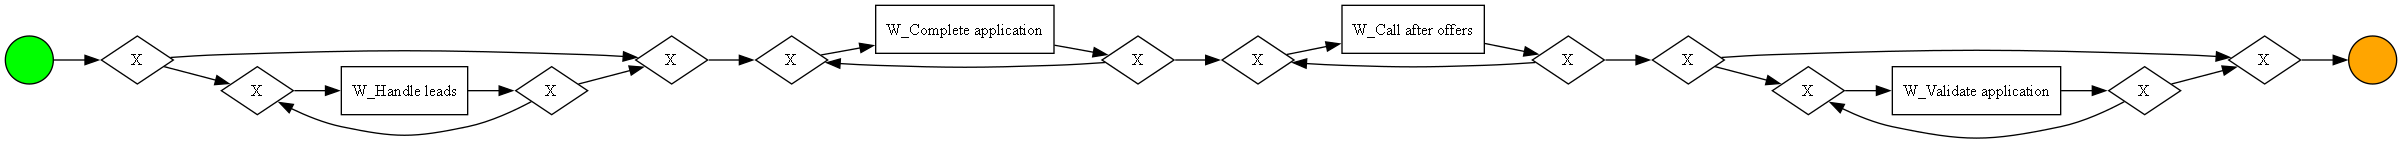

In [ ]:
import pm4py
import pandas as pd


w_df = pm_csv[pm_csv['concept:name'].str.startswith('W_', na=False)]

print(f"Số lượng sự kiện con người (Work Items) giữ lại: {len(w_df)}")


log_human_only = pm4py.convert_to_event_log(w_df)

#Happy Path
log_happy_path = pm4py.filter_variants_top_k(log_human_only, k=5)

process_tree = pm4py.discover_process_tree_inductive(log_happy_path)
bpmn_model = pm4py.convert_to_bpmn(process_tree)

print("Đã vẽ xong sơ đồ công việc thực tế của nhân viên!")
pm4py.view_bpmn(bpmn_model)